# Machine Learning Assignment - G00415845
 
## Workflow
1. Data Loading & Understanding
2. Data Preprocessing
3. Train / Validation / Test Split
4. Model Training
5. Hyperparameter Tuning (Cross-Validation)
6. Model Comparison
7. Final Model Selection
8. Test Set Evaluation (ONLY ONCE)
9. Conclusion

## 1. Setup

This section initialises the environment, imports required libraries, 
and sets a fixed random seed to ensure reproducibility.

In [1]:
# Core
import numpy as np
import pandas as pd

# Image processings
from PIL import Image

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models (we will use these later)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Misc
import time
import os
from datetime import datetime
from pathlib import Path


# TensorFlow (for deep learning models)
import tensorflow as tf
from tensorflow.keras import models, layers
 

In [2]:
RANDOM_STATE = 415845
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [3]:
os.makedirs("logs", exist_ok=True)

def log_run(model_name, params, start_time, end_time, train_acc, val_acc, notes=""):
    
    duration = end_time - start_time
    log_file = "logs/experiment_log.txt"
    
    # Check if the model run is already logged to prevent duplicates
    log_content = ""
    if os.path.exists(log_file):
        with open(log_file, "r") as f:
            log_content = f.read()
            
    if f"Model: {model_name}" in log_content:
        print(f"'{model_name}' is already in the log file. Skipping.")
        return

    entry = f"""
========================================
Time: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
Model: {model_name}
Parameters: {params}
Training Time (s): {duration:.2f}
Train Accuracy: {train_acc:.4f}
Validation Accuracy: {val_acc:.4f}
Notes: {notes}
========================================
"""
    
    with open(log_file, "a") as f:
        f.write(entry)
    print(f"Logged results for '{model_name}'.")

In [4]:
results_df = pd.DataFrame(columns=[
    "Model",
    "Parameters",
    "Train Accuracy",
    "Validation Accuracy",
    "Training Time (s)",
    "Overfitting (Train - Val)",
    "Notes"
])

In [31]:
def add_to_results(df, model_name, params, train_acc, val_acc, training_time, notes=""):
    """
    Adds a new row to the results DataFrame and prevents duplicates.
    """

    # Check if the model is already in the dataframe
    if model_name in df["Model"].values:
        print(f"'{model_name}' is already in the results table. Skipping.")
        return df

    # Calculate overfitting
    overfitting = train_acc - val_acc
    
    # Create a new row as a dictionary
    new_row = {
        "Model": model_name,
        "Parameters": str(params),  # Convert params dict to string for display
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Training Time (s)": training_time,
        "Overfitting (Train - Val)": overfitting,
        "Notes": notes
    }
    
    # Append the new row
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    
    # Save the updated dataframe to a csv file
    df.to_csv("logs/results.csv", index=False)
    
    print(f"Added '{model_name}' to the results table.")
    return df

## 2. Data Loading and Understanding - Garbage Dataset

The dataset consists of images of different types of waste materials.
Each class is stored in a separate folder.

I will:
- Load images
- Convert to feature vectors
- Create labels
- Inspect dataset structure

In [6]:
data_dir = Path("../data/garbage/garbage")

print("Dataset exists:", data_dir.exists())
print("Dataset path:", data_dir.resolve())

Dataset exists: True
Dataset path: C:\Users\norak\Desktop\ML-Assingment G00415845\data\garbage\garbage


In [7]:
# Set up parameters for loading the dataset
IMAGE_SIZE = (128, 128) # will resize all images to this size for consistency
BATCH_SIZE = 32 # will use a batch size of 32 for training our models

# Load the dataset using Keras utility
full_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    seed=RANDOM_STATE,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 12259 files belonging to 10 classes.


### Class Distribution and Imbalance

The dataset exhibits a moderate class imbalance, with the number of samples varying across categories.

For example, the 'clothes' class contains 1892 images, whereas the 'trash' class contains only 453 images. This represents a difference of approximately four times between the largest and smallest classes.

Such imbalance may affect model performance, as models can become biased towards classes with more training samples. This will be considered during evaluation using class-wise metrics such as confusion matrices and classification reports.

In [8]:
# Class distribution
class_names = [d.name for d in data_dir.iterdir() if d.is_dir()]
class_counts = {}

for class_name in class_names:
    class_path = data_dir / class_name
    image_files = [f for f in class_path.iterdir() if f.is_file()]
    class_counts[class_name] = len(image_files)

class_counts

{'battery': 756,
 'biological': 699,
 'cardboard': 1411,
 'clothes': 1892,
 'glass': 1736,
 'metal': 930,
 'paper': 1336,
 'plastic': 1597,
 'shoes': 1449,
 'trash': 453}

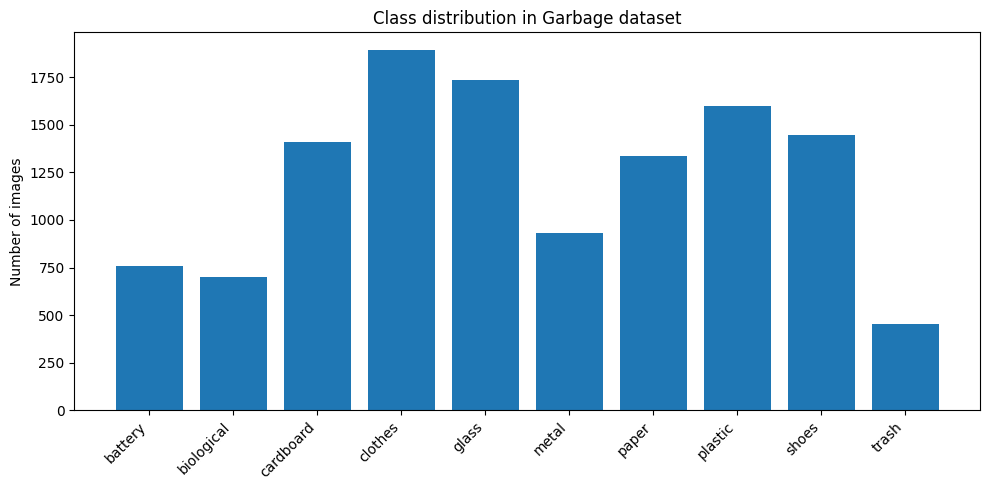

In [9]:
# Visualize class distribution
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("Class distribution in Garbage dataset")
plt.tight_layout()
plt.show()

### Sample Images from the dataset & Pixel Values

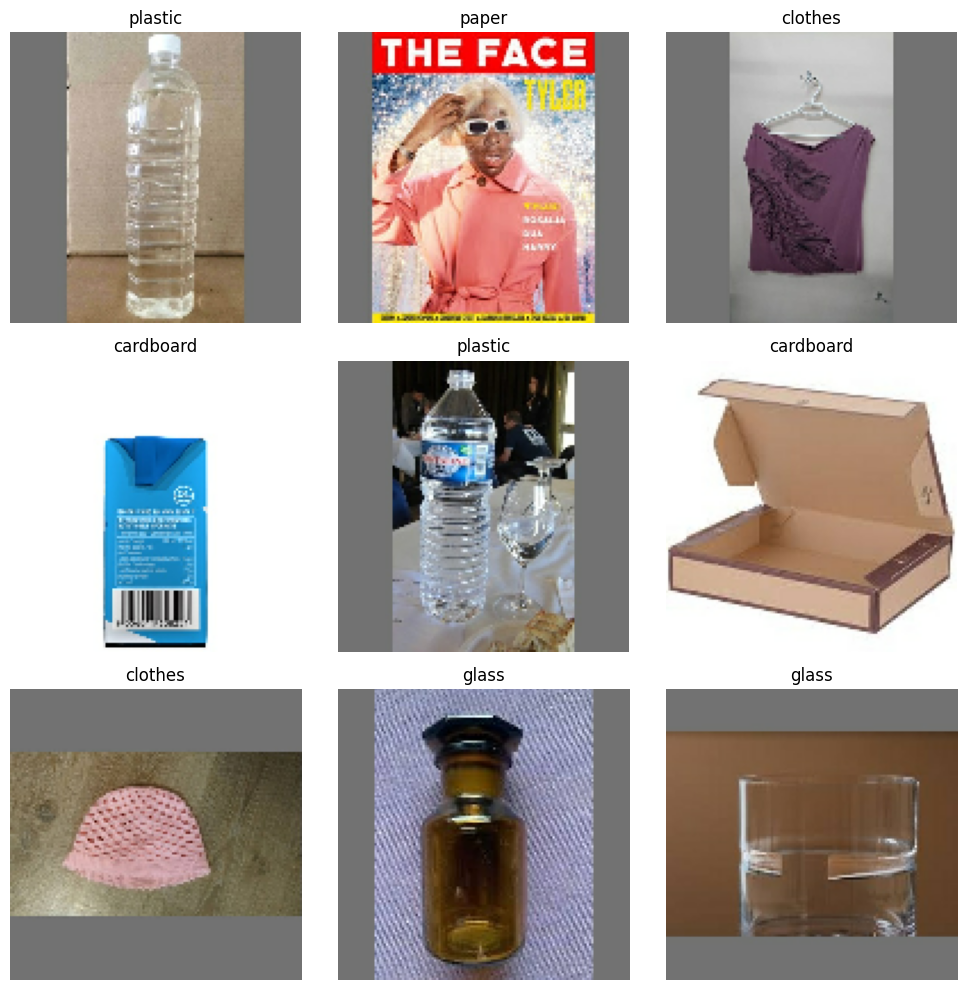

In [10]:
# Sample some images from the dataset
images_batch, labels_batch = next(iter(full_ds))

plt.figure(figsize=(10, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images_batch[i].numpy().astype("uint8"))
    plt.title(full_ds.class_names[labels_batch[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# Check pixel value range and dtype

print("Pixel dtype:", images_batch.dtype)
print("Min pixel value:", tf.reduce_min(images_batch).numpy())
print("Max pixel value:", tf.reduce_max(images_batch).numpy())

Pixel dtype: <dtype: 'float32'>
Min pixel value: 0.0
Max pixel value: 255.0


### Check for Corrupted Images

In [12]:
# Check for corrupted images

bad_files = []

for class_name in class_names:
    class_path = data_dir / class_name
    for file_path in class_path.iterdir():
        try:
            with Image.open(file_path) as img:
                img.verify()  # check if image is valid
        except Exception:
            bad_files.append(file_path)

print("Number of corrupted images:", len(bad_files))

Number of corrupted images: 0


## 3. Train, Validation, and Test Split

In this section, the dataset is divided into training, validation, and test sets.

- The training set is used to train the models
- The validation set is used for model tuning and selection
- The test set is reserved for final evaluation only

A fixed random seed is used to ensure reproducibility of the split.

>A validation set of 10% was selected as it provides a sufficient amount of data for reliable model evaluation while preserving the majority of the dataset for training. 
>Using a larger validation set would reduce the amount of data available for training, while a smaller validation set could lead to unreliable performance estimates.

In [13]:
# First Split: Train (70%) and Temporary (30%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_STATE,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_STATE,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [14]:
# Second Split: split Temporary into Validation (10%) and Test (20%)
temp_size = tf.data.experimental.cardinality(temp_ds).numpy()  # number of batches
val_size = temp_size // 3  # exactly 1/3 of temp 

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

In [15]:
# Check sizes
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
test_batches = tf.data.experimental.cardinality(test_ds).numpy()

print("Train batches:", train_batches)
print("Validation batches:", val_batches)
print("Test batches:", test_batches)

print("-------------------------------")
print("Approx total samples:")
print("Train:", train_batches * BATCH_SIZE)
print("Validation:", val_batches * BATCH_SIZE)
print("Test:", test_batches * BATCH_SIZE)

Train batches: 269
Validation batches: 38
Test batches: 77
-------------------------------
Approx total samples:
Train: 8608
Validation: 1216
Test: 2464


## 4. Preprocessing and Experimental Setup

In this section, the dataset is prepared for model training.

This includes:
- Normalising pixel values
- Defining the input image size
- Preparing for later experiments (RGB vs greyscale, image size comparison, and overfitting control)

The preprocessing pipeline is designed to be consistent across experiments to ensure fair comparison between models.

In [16]:
# An initial image size of (128, 128) selected to reduce computational cost.
IMAGE_SIZE = (128, 128)

In [17]:
# Normalisation layer to scale pixel values to [0, 1]
normalisation_layer = layers.Rescaling(1./255)

In [18]:
# Apply normalization to all datasets
train_ds = train_ds.map(lambda x, y: (normalisation_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalisation_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalisation_layer(x), y))

In [19]:
# Data augmentation pipeline (for training dataset only)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

## 5. CNN From Scratch

In this section, a Convolutional Neural Network (CNN) is built from scratch and trained on the dataset.

An initial baseline model is developed using RGB images. The model's performance is evaluated using the validation set, and signs of overfitting or underfitting are analysed.

Based on these observations, adjustments to the model architecture and hyperparameters will be made in subsequent experiments.

A greyscale version of the model will also be implemented later to compare performance against RGB input.

### 5.1 Baseline CNN (RGB, 128×128)

A baseline CNN model is first developed using RGB images resized to 128×128.

This model serves as a starting point to evaluate performance and identify potential issues such as overfitting or underfitting before making improvements.

In [20]:
model = models.Sequential()

# Input layer
model.add(layers.Input(shape=(128, 128, 3)))

# Convolutional Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Convolutional Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Convolutional Block 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Flatten and Dense layers
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))

# Output layer
model.add(layers.Dense(len(class_names), activation='softmax'))

In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Train the model and measure training time
start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

end_time = time.time()
training_time = end_time - start_time

# Extract final metrics
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Training time:", training_time)


Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 63s 221ms/step - accuracy: 0.3724 - loss: 1.7879 - val_accuracy: 0.5082 - val_loss: 1.3921
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 58s 213ms/step - accuracy: 0.5199 - loss: 1.3738 - val_accuracy: 0.5485 - val_loss: 1.2730
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 61s 226ms/step - accuracy: 0.5820 - loss: 1.2140 - val_accuracy: 0.6151 - val_loss: 1.1757
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 67s 246ms/step - accuracy: 0.6206 - loss: 1.1113 - val_accuracy: 0.6431 - val_loss: 1.1125
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 65s 242ms/step - accuracy: 0.6522 - loss: 1.0265 - val_accuracy: 0.5946 - val_loss: 1.2619
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 80s 235ms/step - accuracy: 0.6691 - loss: 0.9789 - val_accuracy: 0.6579 - val_loss: 1.0544
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 63s 234ms/step - accuracy: 0.6994 - loss: 0.8903 - val_accuracy: 0.6637 - val_loss: 1.0752
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 61s 225ms/step - accuracy: 0.7118 - loss: 0

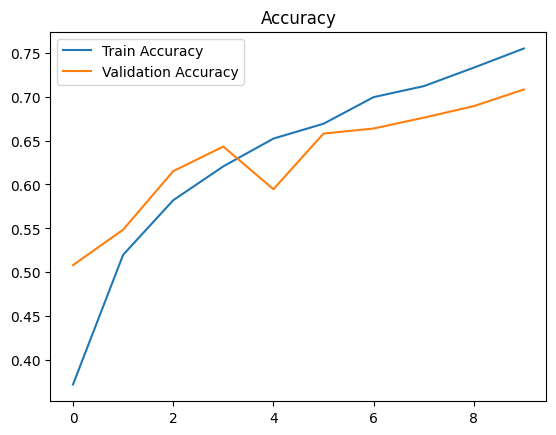

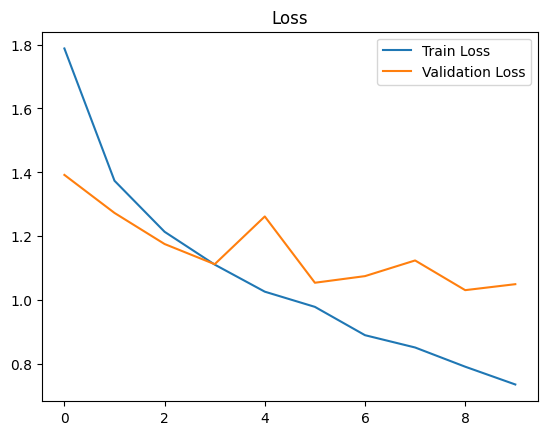

In [23]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [24]:
# Evaluation
train_loss, train_acc = model.evaluate(train_ds)
val_loss, val_acc = model.evaluate(val_ds)

269/269 ━━━━━━━━━━━━━━━━━━━━ 27s 100ms/step - accuracy: 0.7783 - loss: 0.6603
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.7122 - loss: 1.0024


In [33]:
# Log to text file

from matplotlib.dates import _epoch


log_run(
    model_name="Baseline CNN",
    params={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "epochs": 10
    },
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Initial baseline CNN trained on RGB images"
)

# Add to results dataframe
results_df = add_to_results(
    df=results_df,
    model_name="Baseline CNN",
    params={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "epochs": 10
    },
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Initial baseline CNN trained on RGB images"
)

results_df



'Baseline CNN' is already in the log file. Skipping.
Added 'Baseline CNN' to the results table.


,Model,Parameters,Train Accuracy,Validation Accuracy,Training Time (s),Overfitting (Train - Val),Notes
0,Baseline CNN,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.778257,0.712171,644.737963,0.066086,Initial baseline CNN trained on RGB images


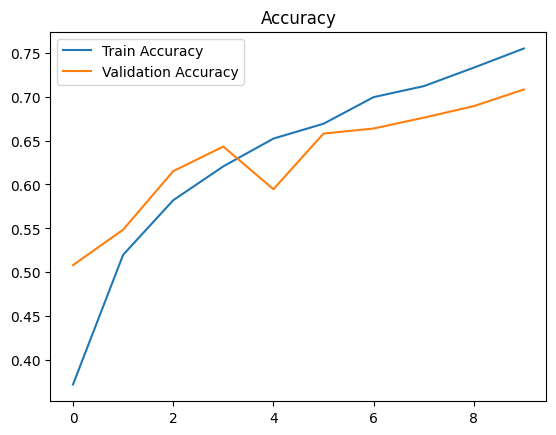

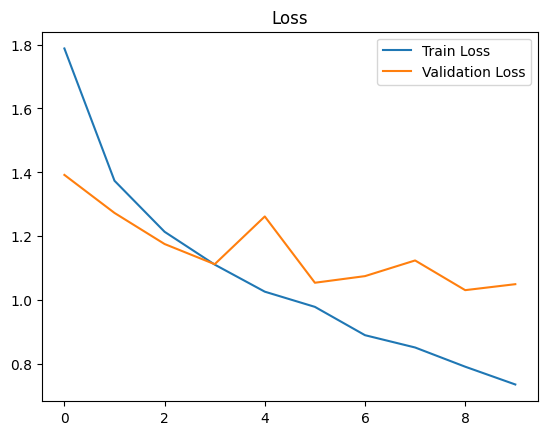

In [34]:
# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

>The learning curves indicate that both training and validation accuracy improve over time, suggesting that the model is successfully learning meaningful features. However, a consistent gap between training and validation performance is observed, along with fluctuations in validation loss. This indicates mild overfitting, where the model begins to specialise on the training data and generalises less effectively to unseen data.

### 5.2 Improved CNN (Dropout)

To address overfitting observed in the baseline model, dropout regularisation is introduced.

>REPORT REFERENCE: @article{JMLR:v15:srivastava14a,
  author  = {Nitish Srivastava and Geoffrey Hinton and Alex Krizhevsky and Ilya Sutskever and Ruslan Salakhutdinov},
  title   = {Dropout: A Simple Way to Prevent Neural Networks from Overfitting},
  journal = {Journal of Machine Learning Research},
  year    = {2014},
  volume  = {15},
  number  = {56},
  pages   = {1929--1958},
  url     = {http://jmlr.org/papers/v15/srivastava14a.html}
}   

In [39]:
model_dropout2 = models.Sequential()

# Input - same as before to ensure fair comparison
model_dropout2.add(layers.Input(shape=(128, 128, 3)))

# Conv blocks
model_dropout2.add(layers.Conv2D(32, (3,3), activation='relu'))
model_dropout2.add(layers.MaxPooling2D((2,2)))

model_dropout2.add(layers.Conv2D(64, (3,3), activation='relu'))
model_dropout2.add(layers.MaxPooling2D((2,2)))

model_dropout2.add(layers.Conv2D(128, (3,3), activation='relu'))
model_dropout2.add(layers.MaxPooling2D((2,2)))

# Dense
model_dropout2.add(layers.Flatten())
model_dropout2.add(layers.Dense(128, activation='relu'))

# Dropout added
model_dropout2.add(layers.Dropout(0.2))

# Output
model_dropout2.add(layers.Dense(len(class_names), activation='softmax'))

In [40]:
# Compile
model_dropout2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
start_time = time.time()

history_dropout = model_dropout2.fit(
    train_ds,
    validation_data=val_ds,
    epochs= 10
)

end_time = time.time()
training_time = end_time - start_time

# Evaluate
train_loss, train_acc = model_dropout2.evaluate(train_ds)
val_loss, val_acc = model_dropout2.evaluate(val_ds)



Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 58s 207ms/step - accuracy: 0.3129 - loss: 1.9301 - val_accuracy: 0.4531 - val_loss: 1.5647
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 50s 185ms/step - accuracy: 0.4611 - loss: 1.5595 - val_accuracy: 0.5378 - val_loss: 1.3432
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 48s 177ms/step - accuracy: 0.5083 - loss: 1.4193 - val_accuracy: 0.5132 - val_loss: 1.4969
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 47s 175ms/step - accuracy: 0.5422 - loss: 1.3289 - val_accuracy: 0.5592 - val_loss: 1.2842
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 48s 177ms/step - accuracy: 0.5684 - loss: 1.2574 - val_accuracy: 0.5847 - val_loss: 1.2120
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 49s 181ms/step - accuracy: 0.5946 - loss: 1.1753 - val_accuracy: 0.5724 - val_loss: 1.3434
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 49s 183ms/step - accuracy: 0.6086 - loss: 1.1283 - val_accuracy: 0.5938 - val_loss: 1.2400
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 48s 179ms/step - accuracy: 0.6332 - loss: 1

In [41]:
# Log
log_run(
    model_name="CNN + Dropout (0.2)",
    params={"epochs": 10, "dropout": 0.2},
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Added dropout to reduce overfitting"
)

# Results table
results_df = add_to_results(
    df=results_df,
    model_name="CNN + Dropout (0.2)",
    params={"epochs": 10, "dropout": 0.2},
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Dropout added"
)

Logged results for 'CNN + Dropout (0.2)'.
Added 'CNN + Dropout (0.2)' to the results table.


>DROPOUT(0.5) : While dropout is commonly used to reduce overfitting, applying a dropout rate of 0.5 led to a decrease in both training and validation accuracy. This suggests that the baseline model was not significantly overfitting, and the added regularisation reduced the model’s capacity to learn meaningful features, resulting in underfitting.

>The baseline CNN achieved the highest validation accuracy, indicating good generalisation despite a small degree of overfitting. Introducing dropout reduced the gap between training and validation accuracy, confirming its regularisation effect. However, both dropout configurations resulted in lower validation performance, suggesting that the baseline model was not significantly overfitting and that additional regularisation led to underfitting.

### 5.3 CNN + Image Resize

In [43]:
IMAGE_SIZE = (64, 64)

In [44]:
# New Split: Train (70%) and Temporary (30%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=RANDOM_STATE,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=RANDOM_STATE,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

# Second Split: split Temporary into Validation (10%) and Test (20%)
temp_size = tf.data.experimental.cardinality(temp_ds).numpy()
val_size = temp_size // 3

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

Found 12259 files belonging to 10 classes.
Using 8582 files for training.
Found 12259 files belonging to 10 classes.
Using 3677 files for validation.


In [45]:
# Normalisation - same as before to ensure fair comparison
model_img64 = models.Sequential()

# Input layer
model_img64.add(layers.Input(shape=(64, 64, 3)))

# Convolutional Block 1
model_img64.add(layers.Conv2D(32, (3,3), activation='relu'))
model_img64.add(layers.MaxPooling2D((2,2)))

# Convolutional Block 2
model_img64.add(layers.Conv2D(64, (3,3), activation='relu'))
model_img64.add(layers.MaxPooling2D((2,2)))

# Convolutional Block 3
model_img64.add(layers.Conv2D(128, (3,3), activation='relu'))
model_img64.add(layers.MaxPooling2D((2,2)))

# Flatten and Dense layers
model_img64.add(layers.Flatten())
model_img64.add(layers.Dense(128, activation='relu'))

# Output layer
model_img64.add(layers.Dense(len(class_names), activation='softmax'))

In [46]:
# Compile
model_img64.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [47]:
# Train the model and measure training time
start_time = time.time()

historyimg64 = model_img64.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

end_time = time.time()
training_time = end_time - start_time

print("Training time:", training_time)


Epoch 1/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.3968 - loss: 3.0522 - val_accuracy: 0.4720 - val_loss: 1.5314
Epoch 2/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.5581 - loss: 1.2990 - val_accuracy: 0.5255 - val_loss: 1.4038
Epoch 3/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.6424 - loss: 1.0607 - val_accuracy: 0.5872 - val_loss: 1.2780
Epoch 4/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.7002 - loss: 0.8807 - val_accuracy: 0.5789 - val_loss: 1.3714
Epoch 5/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.7543 - loss: 0.7178 - val_accuracy: 0.5987 - val_loss: 1.4386
Epoch 6/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.8032 - loss: 0.5655 - val_accuracy: 0.5880 - val_loss: 1.5554
Epoch 7/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.8303 - loss: 0.4875 - val_accuracy: 0.5765 - val_loss: 1.6978
Epoch 8/10
269/269 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.8620 - loss: 0.4044 - 

In [48]:
# Evaluation
train_loss, train_acc = model_img64.evaluate(train_ds)
val_loss, val_acc = model_img64.evaluate(val_ds)

269/269 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.8789 - loss: 0.3630
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5806 - loss: 2.1481


In [49]:
# Log to text file

from matplotlib.dates import _epoch


log_run(
    model_name="Baseline CNN (64 x 64 img)",
    params={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "epochs": 10
    },
    start_time=start_time,
    end_time=end_time,
    train_acc=train_acc,
    val_acc=val_acc,
    notes="Initial baseline CNN trained on 64x64 images"
)

# Add to results dataframe
results_df = add_to_results(
    df=results_df,
    model_name="Baseline CNN (64 x 64 img)",
    params={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "epochs": 10
    },
    train_acc=train_acc,
    val_acc=val_acc,
    training_time=training_time,
    notes="Initial baseline CNN trained on 64x64 images"
)

results_df



Logged results for 'Baseline CNN (64 x 64 img)'.
Added 'Baseline CNN (64 x 64 img)' to the results table.


,Model,Parameters,Train Accuracy,Validation Accuracy,Training Time (s),Overfitting (Train - Val),Notes
0,Baseline CNN,"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.778257,0.712171,644.737963,0.066086,Initial baseline CNN trained on RGB images
1,CNN + Dropout,"{'epochs': 10, 'dropout': 0.5}",0.701585,0.654605,580.465765,0.046979,Dropout added
2,CNN + Dropout (0.2),"{'epochs': 10, 'dropout': 0.2}",0.714519,0.657072,494.6004,0.057446,Dropout added
3,Baseline CNN (64 x 64 img),"{'optimizer': 'adam', 'loss': 'sparse_categori...",0.878933,0.580592,152.95437,0.298341,Initial baseline CNN trained on 64x64 images


>Reducing the image size to 64×64 resulted in significantly higher training accuracy but substantially lower validation accuracy. This indicates severe overfitting, as the model is able to memorise patterns in the training data but fails to generalise to unseen data. The reduction in image resolution likely removes important visual features, making it harder for the model to learn robust representations across classes.

>The 128×128 image size provides a better balance between computational efficiency and feature preservation. While reducing the image size to 64×64 improved training speed, it significantly reduced validation performance, indicating loss of important visual information. Therefore, 128×128 was selected for subsequent experiments.